In [1]:
import numpy as np
from numpy import pi, arccos, cos, sin, tan, mean
import matplotlib.pyplot as plt
from cats.cdataframe import CDataFrame
import glob
import pandas as pd

Welcome to JupyROOT 6.28/10


In [11]:
colors = {'noIV_noLuke': '#3D6CA5',
          'noIV_Luke_sampleLuke0': '#92C0DC',
          'noIV_Luke_sampleLuke1': '#D72B22',
          'IV_Luke_sampleLuke1': '#FC8D57'}

label = {'noIV_noLuke': r'$\overline{OFF\,\,\,\,\,\,\,\,\,\,\,OFF\,\,\,\,\,\,\,\,\,\,\,\,OFF\,\,\,\,\,\,\,\,\,\,\,\,\,\,}$',
          'noIV_Luke_sampleLuke0': r'$OFF\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,OFF\,\,\,\,\,\,\,\,\,\,\,\,\,\,$',
          'noIV_Luke_sampleLuke1': r'$OFF\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,$',
          'IV_Luke_sampleLuke1': r'$ON\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,$'}

In [12]:
Vs = [0, 4, 10, 20, 30, 40, 50]
runs = ['noIV_noLuke', 'noIV_Luke_sampleLuke0', 'noIV_Luke_sampleLuke1', 'IV_Luke_sampleLuke1']

DMC_filenames = {run: {V: sorted(glob.glob(f'/scratch/group/mitchcomp/CDMS/data/perry5334/runtime_samples/{run}/{run}_{V}V_51240826_0000??.root')) for V in Vs} for run in runs}

In [13]:
Elapsed = {run: {V: None for V in Vs} for run in runs}
UserCPU = {run: {V: None for V in Vs} for run in runs}

for run in runs:
    for V in Vs:
        runtime = CDataFrame('G4SettingsInfoDir/runtime', DMC_filenames[run][V])
        Elapsed[run][V] = runtime.AsNumpy(['Elapsed'])['Elapsed'] * 5 / 20
        UserCPU[run][V] = runtime.AsNumpy(['UserCPU'])['UserCPU'] * 5 / 20

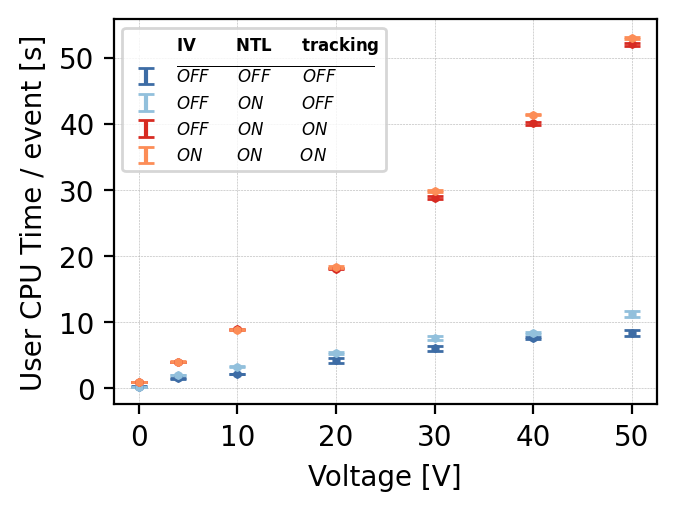

In [14]:
plt.figure(figsize=(3.5,2.5), dpi=200)

# Header using pseudo-data placed away from grid and other data points
plt.errorbar(np.array(Vs[:-1]) + 5, [5 for V in Vs[:-1]], yerr = [0 for V in Vs[:-1]], ls = "None", color='white', capsize = 3, 
             label=r'$\mathbf{IV\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,NTL\,\,\,\,\,\,\,\,\,\,\,tracking}$')

UserCPU_data = {run: {'mean': None, 'std': None} for run in runs}

for run in runs:

    UserCPU_mean = np.array([np.mean(UserCPU[run][V]) for V in Vs])
    UserCPU_std = np.array([np.std(UserCPU[run][V]) / np.sqrt(len(UserCPU[run][V])) for V in Vs])
    UserCPU_data[run]['mean'] = UserCPU_mean
    UserCPU_data[run]['std'] = UserCPU_std

    plt.errorbar(Vs, UserCPU_mean, yerr = UserCPU_std, ls = "None", color=colors[run], capsize = 3,
             label=label[run])
    plt.scatter(Vs, UserCPU_mean, s = 5, marker = "h", zorder=10, color=colors[run])

plt.xlabel('Voltage [V]')
plt.ylabel('User CPU Time / event [s]')
plt.legend(fontsize = 6)
#plt.tight_layout()
plt.grid(lw = 0.2, ls = '--')

#plt.savefig('figures/CPUTime.png')

noIV_noLuke
0
4
10
20
30
40
50
noIV_Luke_sampleLuke0
0
4
10
20
30
40
50
noIV_Luke_sampleLuke1
0
4
10
20
30
40
50
IV_Luke_sampleLuke1
0
4
10
20
30
40
50


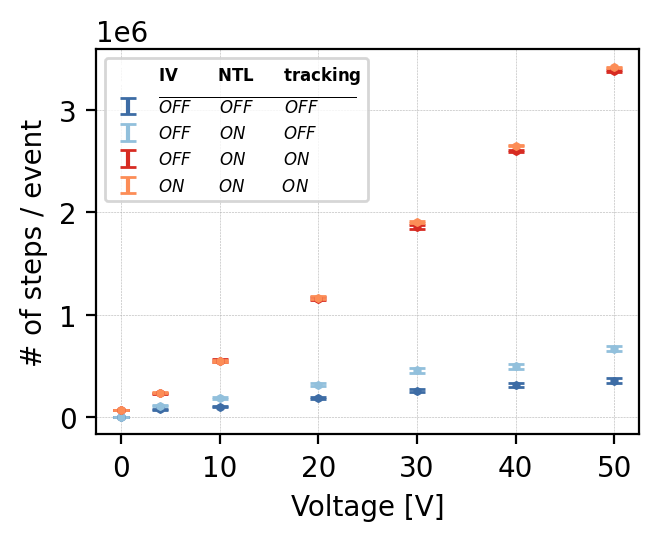

In [8]:
plt.figure(figsize=(3.5,2.5), dpi=200)

# Header using pseudo-data placed away from grid and other data points
plt.errorbar(np.array(Vs[:-1]) + 5, [2.5e6 for V in Vs[:-1]], yerr = [0 for V in Vs[:-1]], ls = "None", color='white', capsize = 3, 
             label=r'$\mathbf{IV\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,NTL\,\,\,\,\,\,\,\,\,\,\,tracking}$')

steps_data = {run: {'mean': None, 'std': None} for run in runs}

for run in runs:
    print(run)
    steps_mean = []
    steps_std = []
    for V in Vs:
        print(V)
        steps = []
        mcHitCounter = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[run][V])
        Events = np.unique(mcHitCounter.AsNumpy(['EventNum'])['EventNum'])
        data = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[run][V]).AsNumpy(['EventNum', 'TrkStep'])
        for event in Events:
            eventCut = data['EventNum'] == event
            steps.append(len(data['TrkStep'][eventCut]))
    
        steps_mean.append(np.mean(steps))
        steps_std.append(np.std(steps) / np.sqrt(len(steps)))

    steps_data[run]['mean'] = np.array(steps_mean)
    steps_data[run]['std'] = np.array(steps_std)
    plt.errorbar(Vs, steps_mean, yerr = steps_std, ls = "None", color=colors[run], capsize = 3,
                label=label[run])
    plt.scatter(Vs, steps_mean, s = 5, marker = "h", zorder=10, color=colors[run])

plt.xlabel('Voltage [V]')
plt.ylabel('# of steps / event')
plt.legend(fontsize = 6, loc = 'upper left')
#plt.tight_layout()
plt.grid(lw = 0.2, ls = '--')

In [9]:
label = {'noIV_Luke_sampleLuke1': r'$\overline{OFF\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,}$',
          'IV_Luke_sampleLuke1': r'$ON\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,$'}

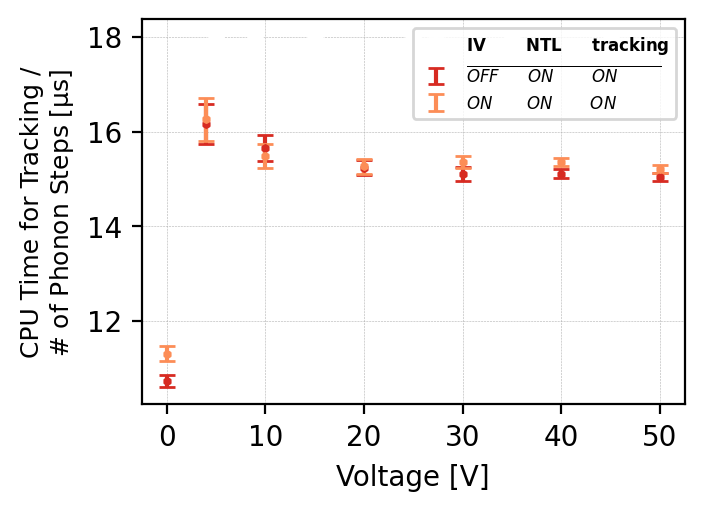

In [10]:
plt.figure(figsize=(3.5,2.5), dpi=200)

# Header using pseudo-data placed away from grid and other data points
plt.errorbar(np.array(Vs[:-1]) + 5, [18 for V in Vs[:-1]], yerr = [0 for V in Vs[:-1]], ls = "None", color='white', capsize = 3, 
             label=r'$\mathbf{IV\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,NTL\,\,\,\,\,\,\,\,\,\,\,tracking}$')

for run in ['noIV_Luke_sampleLuke1', 'IV_Luke_sampleLuke1']:

    tracking_diff = UserCPU_data[run]['mean'] - UserCPU_data['noIV_Luke_sampleLuke0']['mean']
    tracking_std = np.sqrt(UserCPU_data[run]['std']**2 + UserCPU_data['noIV_Luke_sampleLuke0']['std']**2)

    steps_diff = steps_data[run]['mean'] - steps_data['noIV_Luke_sampleLuke0']['mean']
    steps_std = np.sqrt(steps_data[run]['std']**2 + steps_data['noIV_Luke_sampleLuke0']['std']**2)

    ratio = tracking_diff / steps_diff
    ratio_std = ratio * np.sqrt( (tracking_std / tracking_diff)**2 + (steps_std / steps_diff) **2 ) / np.sqrt(len(ratio))
    
    plt.errorbar(Vs, ratio * 1e6, yerr = ratio_std * 1e6, ls = "None", color=colors[run], capsize = 3,
                label=label[run])
    plt.scatter(Vs, ratio * 1e6, s = 5, marker = "h", zorder=10, color=colors[run])

plt.xlabel('Voltage [V]')
plt.ylabel('CPU Time for Tracking /' + '\n' + r'# of Phonon Steps [$\mathrm{\mu s}$]', fontsize = 9)
plt.legend(fontsize = 6, loc = 'upper right')
#plt.tight_layout()
plt.grid(lw = 0.2, ls = '--')

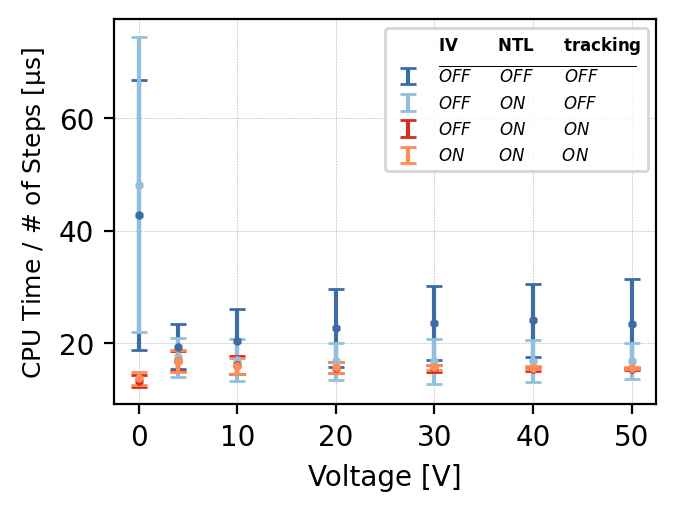

In [54]:
plt.figure(figsize=(3.5,2.5), dpi=200)

# Header using pseudo-data placed away from grid and other data points
plt.errorbar(np.array(Vs[:-1]) + 5, [50 for V in Vs[:-1]], yerr = [0 for V in Vs[:-1]], ls = "None", color='white', capsize = 3, 
             label=r'$\mathbf{IV\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,NTL\,\,\,\,\,\,\,\,\,\,\,tracking}$')

for run in runs:

    tracking = UserCPU_data[run]['mean']
    tracking_std = UserCPU_data[run]['std']

    steps = steps_data[run]['mean']
    steps_std = steps_data[run]['std']

    ratio = tracking / steps
    ratio_std = ratio * np.sqrt( (tracking_std / tracking)**2 + (steps_std / steps) **2 )
    
    plt.errorbar(Vs, ratio * 1e6, yerr = ratio_std * 1e6, ls = "None", color=colors[run], capsize = 3,
                label=label[run])
    plt.scatter(Vs, ratio * 1e6, s = 5, marker = "h", zorder=10, color=colors[run])

plt.xlabel('Voltage [V]')
plt.ylabel(r'CPU Time / # of Steps [$\mathrm{\mu s}$]', fontsize = 9)
plt.legend(fontsize = 6, loc = 'upper right')
#plt.tight_layout()
plt.grid(lw = 0.2, ls = '--')

In [15]:
label = {'noIV_Luke_sampleLuke1': r'$\overline{OFF\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,}$',
          'IV_Luke_sampleLuke1': r'$ON\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,ON\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,$'}

noIV_Luke_sampleLuke1
0
4
10
20
30
40
50
IV_Luke_sampleLuke1
0
4
10
20
30
40
50


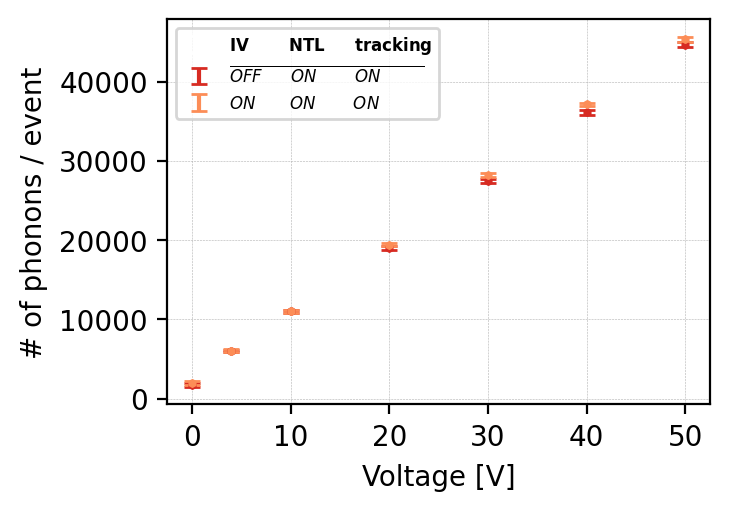

In [8]:
plt.figure(figsize=(3.5,2.5), dpi=200)

# Header using pseudo-data placed away from grid and other data points
plt.errorbar(np.array(Vs[:-1]) + 5, [35000 for V in Vs[:-1]], yerr = [0 for V in Vs[:-1]], ls = "None", color='white', capsize = 3, 
             label=r'$\mathbf{IV\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,NTL\,\,\,\,\,\,\,\,\,\,\,tracking}$')

phonon_data = {run: {'mean': None, 'std': None} for run in runs}

for run in ['noIV_Luke_sampleLuke1', 'IV_Luke_sampleLuke1']:
    print(run)
    steps_mean = []
    steps_std = []
    for V in Vs:
        print(V)
        steps = []
        mcHitCounter = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[run][V])
        Events = np.unique(mcHitCounter.AsNumpy(['EventNum'])['EventNum'])
        data = CDataFrame('G4SimDir/mcHitCounter', DMC_filenames[run][V]).AsNumpy(['EventNum', 'TrkStep'])
        for event in Events:
            eventCut = data['EventNum'] == event
            steps.append(len(np.unique(data['TrkStep'][eventCut] // 100000)))
    
        steps_mean.append(np.mean(steps))
        steps_std.append(np.std(steps) / np.sqrt(len(steps)))

    phonon_data[run]['mean'] = np.array(steps_mean)
    phonon_data[run]['std'] = np.array(steps_std)
    plt.errorbar(Vs, steps_mean, yerr = steps_std, ls = "None", color=colors[run], capsize = 3,
                label=label[run])
    plt.scatter(Vs, steps_mean, s = 5, marker = "h", zorder=10, color=colors[run])

plt.xlabel('Voltage [V]')
plt.ylabel('# of phonons / event')
plt.legend(fontsize = 6, loc = 'upper left')
#plt.tight_layout()
plt.grid(lw = 0.2, ls = '--')

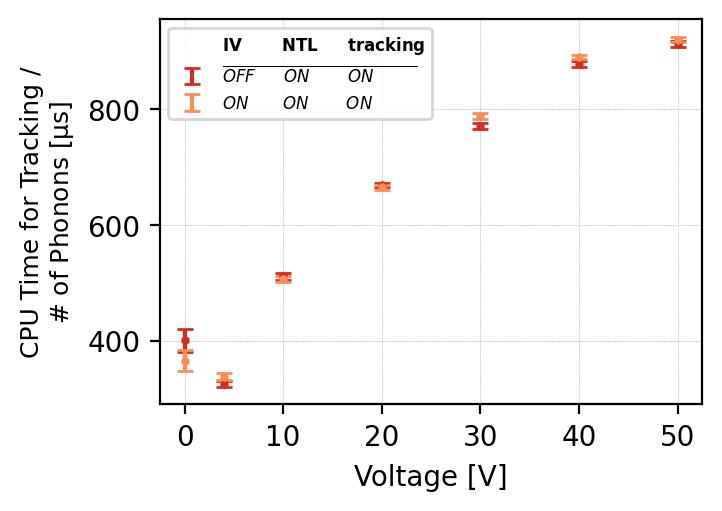

In [16]:
plt.figure(figsize=(3.5,2.5), dpi=200)

# Header using pseudo-data placed away from grid and other data points
plt.errorbar(np.array(Vs[:-1]) + 5, [700 for V in Vs[:-1]], yerr = [0 for V in Vs[:-1]], ls = "None", color='white', capsize = 3, 
             label=r'$\mathbf{IV\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,NTL\,\,\,\,\,\,\,\,\,\,\,tracking}$')

for run in ['noIV_Luke_sampleLuke1', 'IV_Luke_sampleLuke1']:

    tracking_diff = UserCPU_data[run]['mean'] - UserCPU_data['noIV_Luke_sampleLuke0']['mean']
    tracking_std = np.sqrt(UserCPU_data[run]['std']**2 + UserCPU_data['noIV_Luke_sampleLuke0']['std']**2)

    ratio = tracking_diff / phonon_data[run]['mean']
    ratio_std = ratio * np.sqrt( (tracking_std / tracking_diff)**2 + (phonon_data[run]['std'] / phonon_data[run]['mean']) **2 )
    
    plt.errorbar(Vs, ratio * 1e6, yerr = ratio_std / np.sqrt(len(ratio_std)) * 1e6, ls = "None", color=colors[run], capsize = 3,
                label=label[run])
    plt.scatter(Vs, ratio * 1e6, s = 5, marker = "h", zorder=10, color=colors[run])

plt.xlabel('Voltage [V]')
plt.ylabel('CPU Time for Tracking /' + '\n' + r'# of Phonons [$\mathrm{\mu s}$]', fontsize = 9)
plt.legend(fontsize = 6, loc = 'upper left')
#plt.tight_layout()
plt.grid(lw = 0.2, ls = '--')